# HybridSN 光谱预处理方法对比实验

本 Notebook 只读加载已经完成的五路线正式对比，不重新训练或重新选择 checkpoint。
比较目标是回答：是否需要 PCA、标准化是否重要、PCA whitening 是否有效，以及
直接输入选定原始波段能否替代 PCA。

固定协议：`fair24_6_70`、split seed1442、训练 seed1442、30 epoch、验证集 OA 选
checkpoint、统一 `1×15×25×25` 输入和同一 HybridSN。


## 1. 读取冻结的对比运行

正式运行必须包含五个完整变体、汇总 CSV、环境记录和分类图。这里的“回放”不会
访问原始测试 DataLoader，只读取已保存的指标与 PNG，因此不会产生新的测试选择。


In [1]:
from pathlib import Path
import json
import shutil
import sys

import numpy as np
import pandas as pd
from IPython.display import Image, display

def find_project_root(start: Path) -> Path:
    for candidate in (start.resolve(), *start.resolve().parents):
        if (candidate / 'pyproject.toml').is_file():
            return candidate
    raise FileNotFoundError('Cannot locate hsi_project/pyproject.toml')

PROJECT_ROOT = find_project_root(Path.cwd())
PREFERRED_RUN = (
    PROJECT_ROOT / 'experiments'
    / 'hybridsn_preprocessing_comparison__fair24_6_70__seed1442__latest'
)
candidates = [PREFERRED_RUN] + sorted(
    (PROJECT_ROOT / 'experiments').glob(
        'hybridsn_preprocessing_comparison__fair24_6_70__seed1442__*'
    ),
    reverse=True,
)
RUN_DIR = next(
    (path for path in candidates if (path / 'status.json').is_file()
     and json.loads((path / 'status.json').read_text(encoding='utf-8')).get('status') == 'complete'),
    None,
)
if RUN_DIR is None:
    raise FileNotFoundError('No complete preprocessing comparison run was found.')

summary = pd.read_csv(RUN_DIR / 'comparison_summary.csv', encoding='utf-8-sig')
assert len(summary) == 5
assert summary['parameters'].nunique() == 1
assert set(summary['epochs']) == {30}
print(f'正式对比运行 / Formal comparison: {RUN_DIR.relative_to(PROJECT_ROOT)}')
print('所有五条路线使用相同的 4,844,793 参数 HybridSN。')


正式对比运行 / Formal comparison: experiments\hybridsn_preprocessing_comparison__fair24_6_70__seed1442__20260817-1300
所有五条路线使用相同的 4,844,793 参数 HybridSN。


## 2. 汇总结果


In [2]:
result_table = summary[[
    'display_name', 'best_epoch', 'validation_oa', 'test_oa',
    'test_aa', 'test_kappa', 'test_errors', 'training_seconds',
]].copy()
result_table.columns = [
    '方法', '最佳epoch', 'Validation OA', 'Test OA',
    'Test AA', 'Kappa', '错分像元', '训练耗时(s)',
]
display(result_table.style.format({
    'Validation OA': '{:.4%}',
    'Test OA': '{:.4%}',
    'Test AA': '{:.4%}',
    'Kappa': '{:.6f}',
    '训练耗时(s)': '{:.2f}',
}).highlight_max(subset=['Validation OA'], color='#D9EAD3'))

best_validation = summary['validation_oa'].max()
tied = summary[np.isclose(summary['validation_oa'], best_validation)]
print('验证集最高方法：', '、'.join(tied['display_name']))
if len(tied) > 1:
    earliest = tied.sort_values(['best_epoch', 'variant_key']).iloc[0]
    print(f"若预先采用同分时最早轮次优先：{earliest['display_name']}（第{int(earliest['best_epoch'])}轮）")
test_best = summary.sort_values(['test_oa', 'variant_key'], ascending=[False, True]).iloc[0]
print(f"单次测试 OA 数值最高：{test_best['display_name']}（仅描述，不用于选模）")
print('注意：测试指标只作冻结模型结果描述，不用于反向选择方法。')


,方法,最佳epoch,Validation OA,Test OA,Test AA,Kappa,错分像元,训练耗时(s)
0,标准化 + PCA15,25,100.0000%,99.9532%,99.9405%,0.999381,14,125.79
1,原始数值 + PCA15,30,94.5851%,94.9773%,87.8610%,0.933291,1504,127.34
2,标准化 + PCA15 whitening,28,99.9610%,99.9132%,99.8587%,0.998849,26,126.30
3,标准化 + 均匀15波段,16,99.9221%,99.9299%,99.8790%,0.999071,21,124.92
4,标准化 + Fisher 15波段,29,99.7273%,99.7095%,99.4775%,0.996151,87,178.04


验证集最高方法： 标准化 + PCA15
单次测试 OA 数值最高：标准化 + PCA15（仅描述，不用于选模）
注意：测试指标只作冻结模型结果描述，不用于反向选择方法。


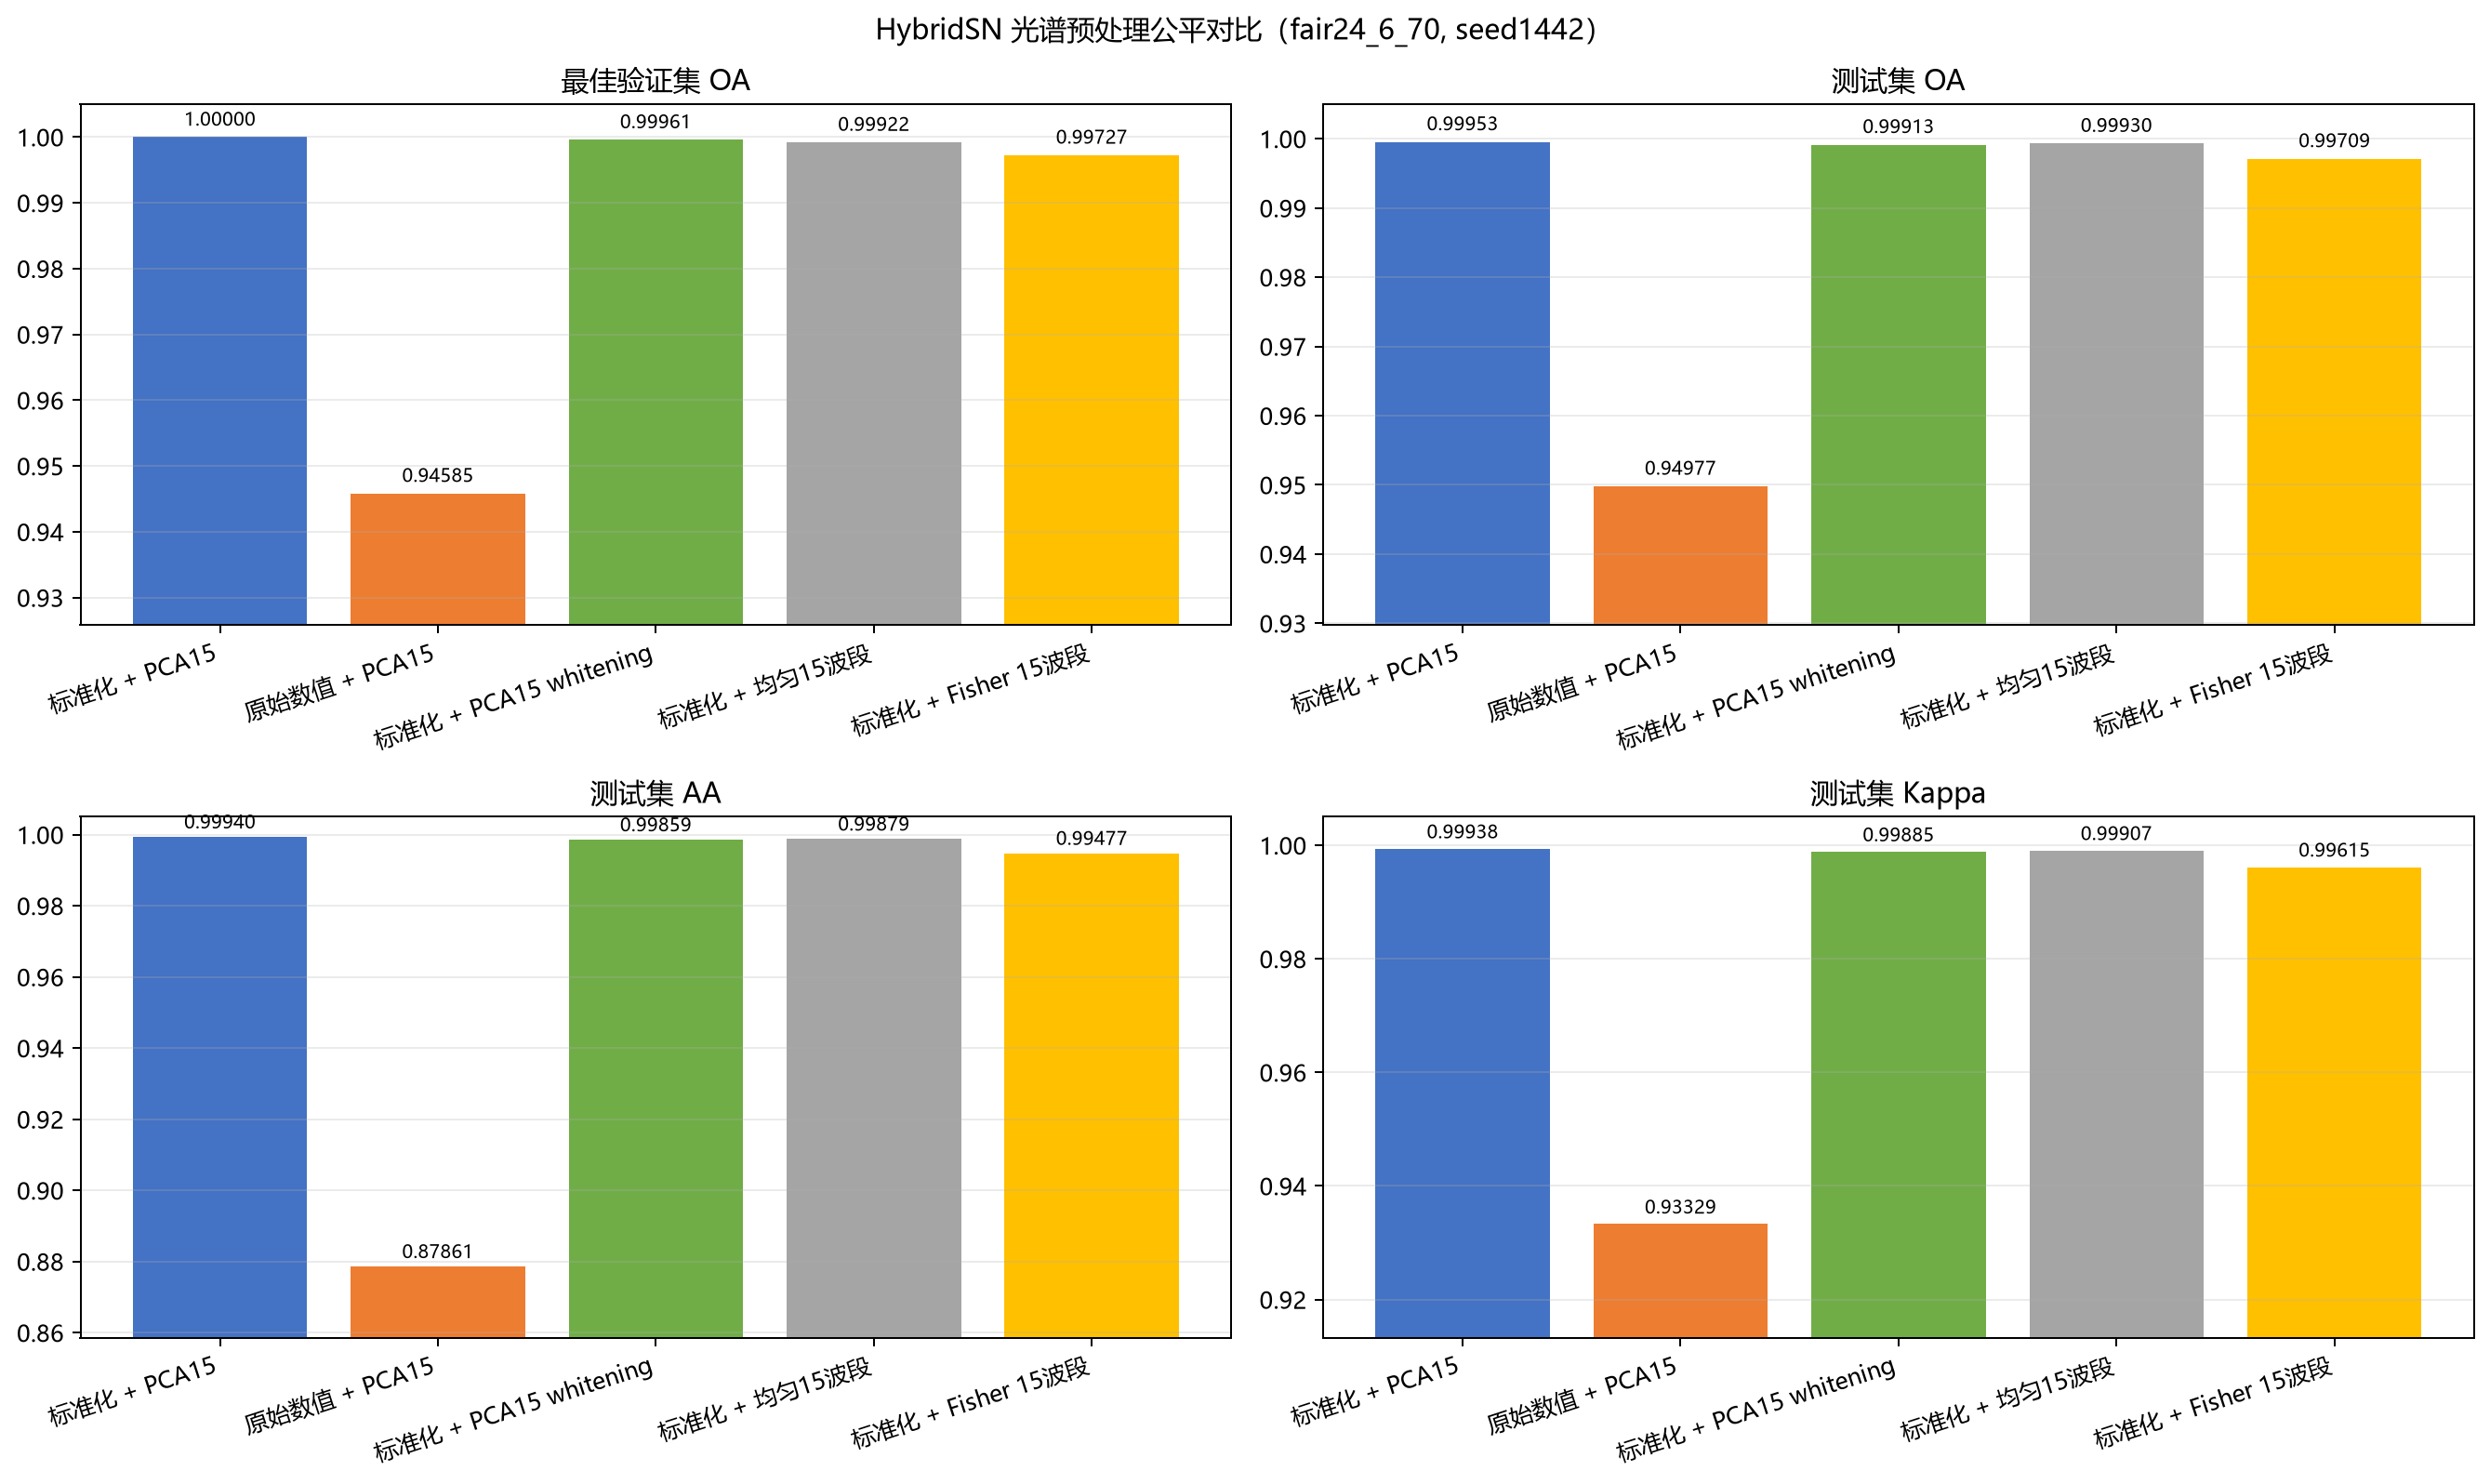

In [3]:
display(Image(filename=str(RUN_DIR / 'comparison_metrics.png'), width=1200))


## 3. 五种光谱表示

PCA 路线保存解释方差；直接波段路线保存真实波段编号。Fisher 分数只由训练集标签
计算；需要结合实际选出的波段范围与验证/测试结果，判断单波段判别力能否替代
全谱覆盖。


In [4]:
variant_details = []
for row in summary.itertuples(index=False):
    metadata = json.loads(
        (RUN_DIR / row.variant_key / 'preprocessing_metadata.json').read_text(encoding='utf-8')
    )
    selected = metadata['selected_band_numbers_one_based']
    variant_details.append({
        '方法': metadata['display_name'],
        '标准化': metadata['standardization'],
        '处理方法': metadata['method'],
        'PCA whitening': metadata['whiten'],
        '直接保留的原始波段': '' if selected is None else ', '.join(map(str, selected)),
        '仅训练集拟合': not metadata['fit_scope']['validation_and_test_used_for_fit'],
        '预处理耗时(s)': row.preprocessing_seconds,
    })
variant_detail_table = pd.DataFrame(variant_details)
display(variant_detail_table.style.format({'预处理耗时(s)': '{:.4f}'}))


,方法,标准化,处理方法,PCA whitening,直接保留的原始波段,仅训练集拟合,预处理耗时(s)
0,标准化 + PCA15,standard,pca,False,,True,0.4496
1,原始数值 + PCA15,none,pca,False,,True,0.5209
2,标准化 + PCA15 whitening,standard,pca,True,,True,0.5554
3,标准化 + 均匀15波段,standard,uniform_band_selection,False,"1, 8, 16, 23, 30, 37, 45, 52, 59, 67, 74, 81, 88, 96, 103",True,0.2783
4,标准化 + Fisher 15波段,standard,fisher_band_selection,False,"7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21",True,0.2768


## 4. 逐类准确率和分类图


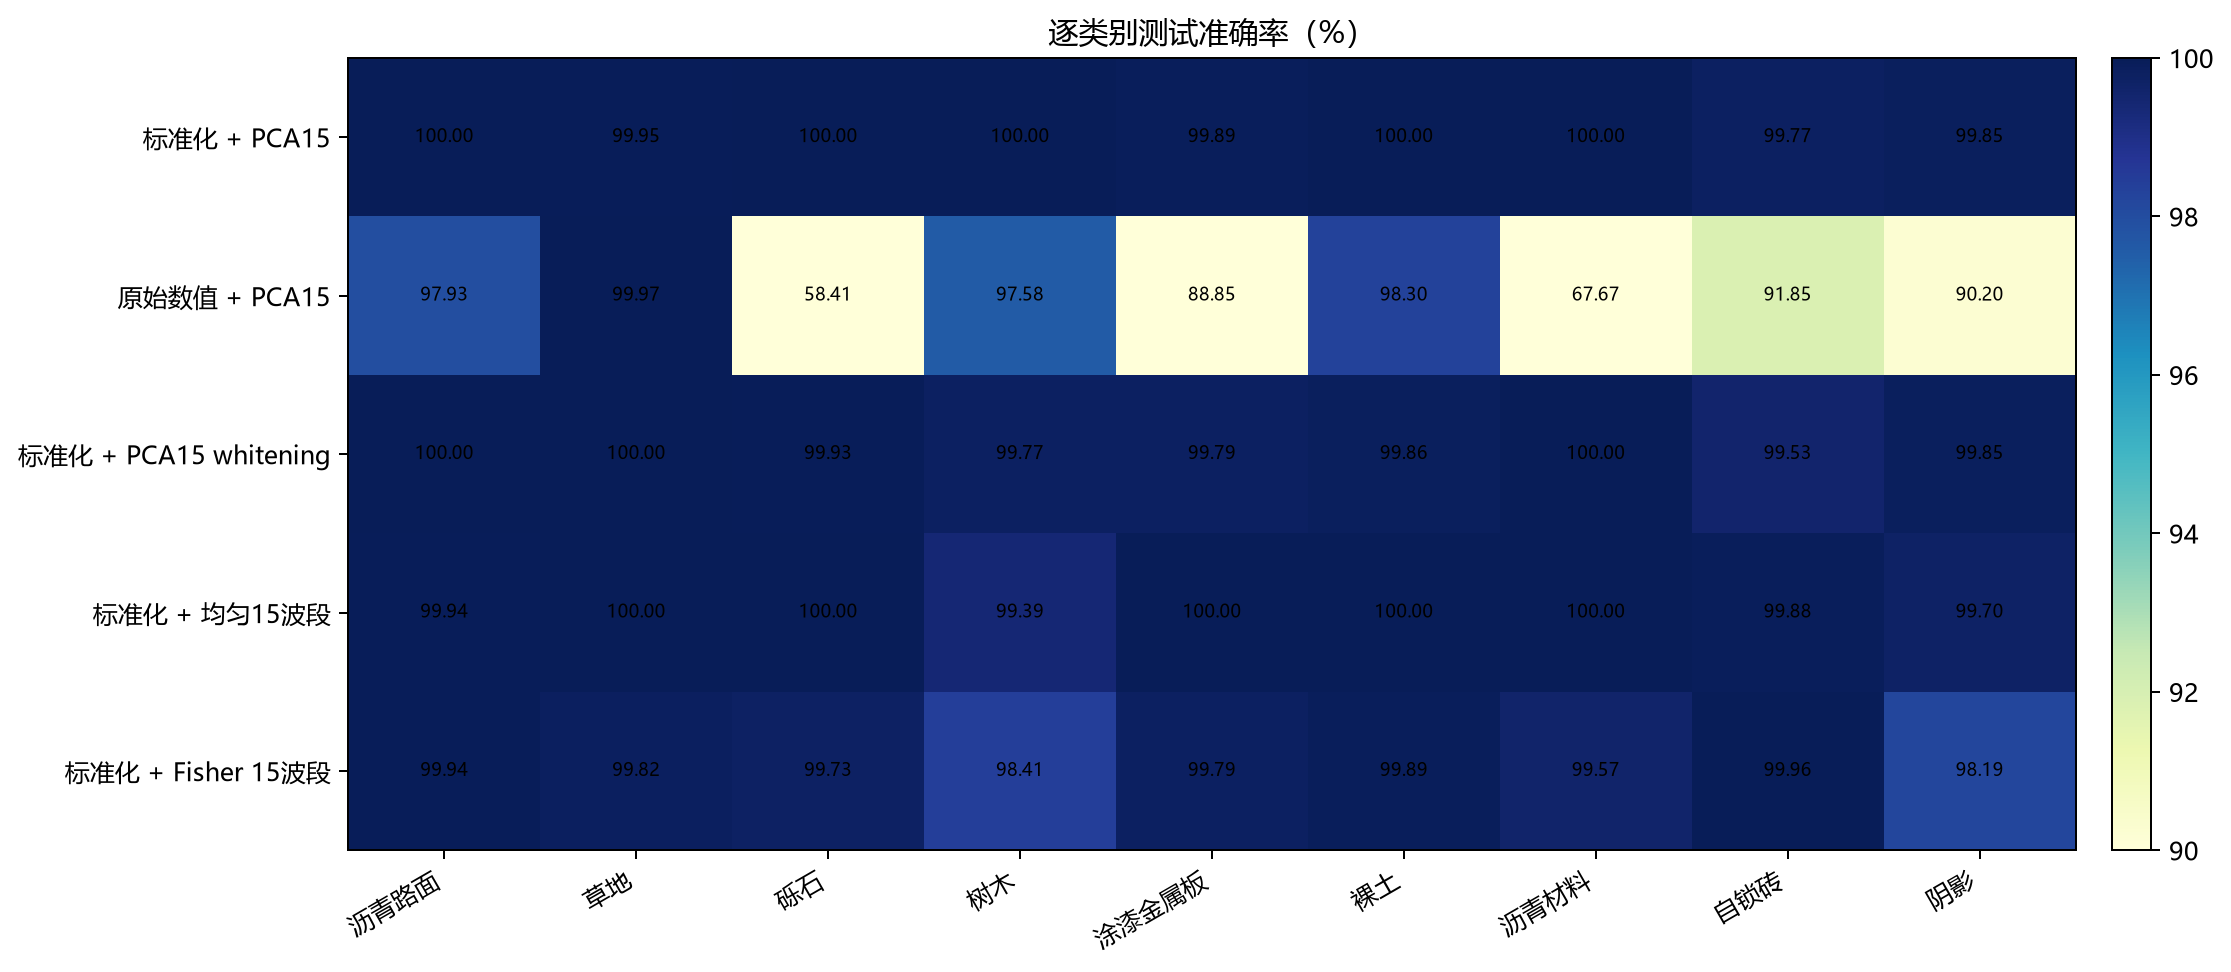

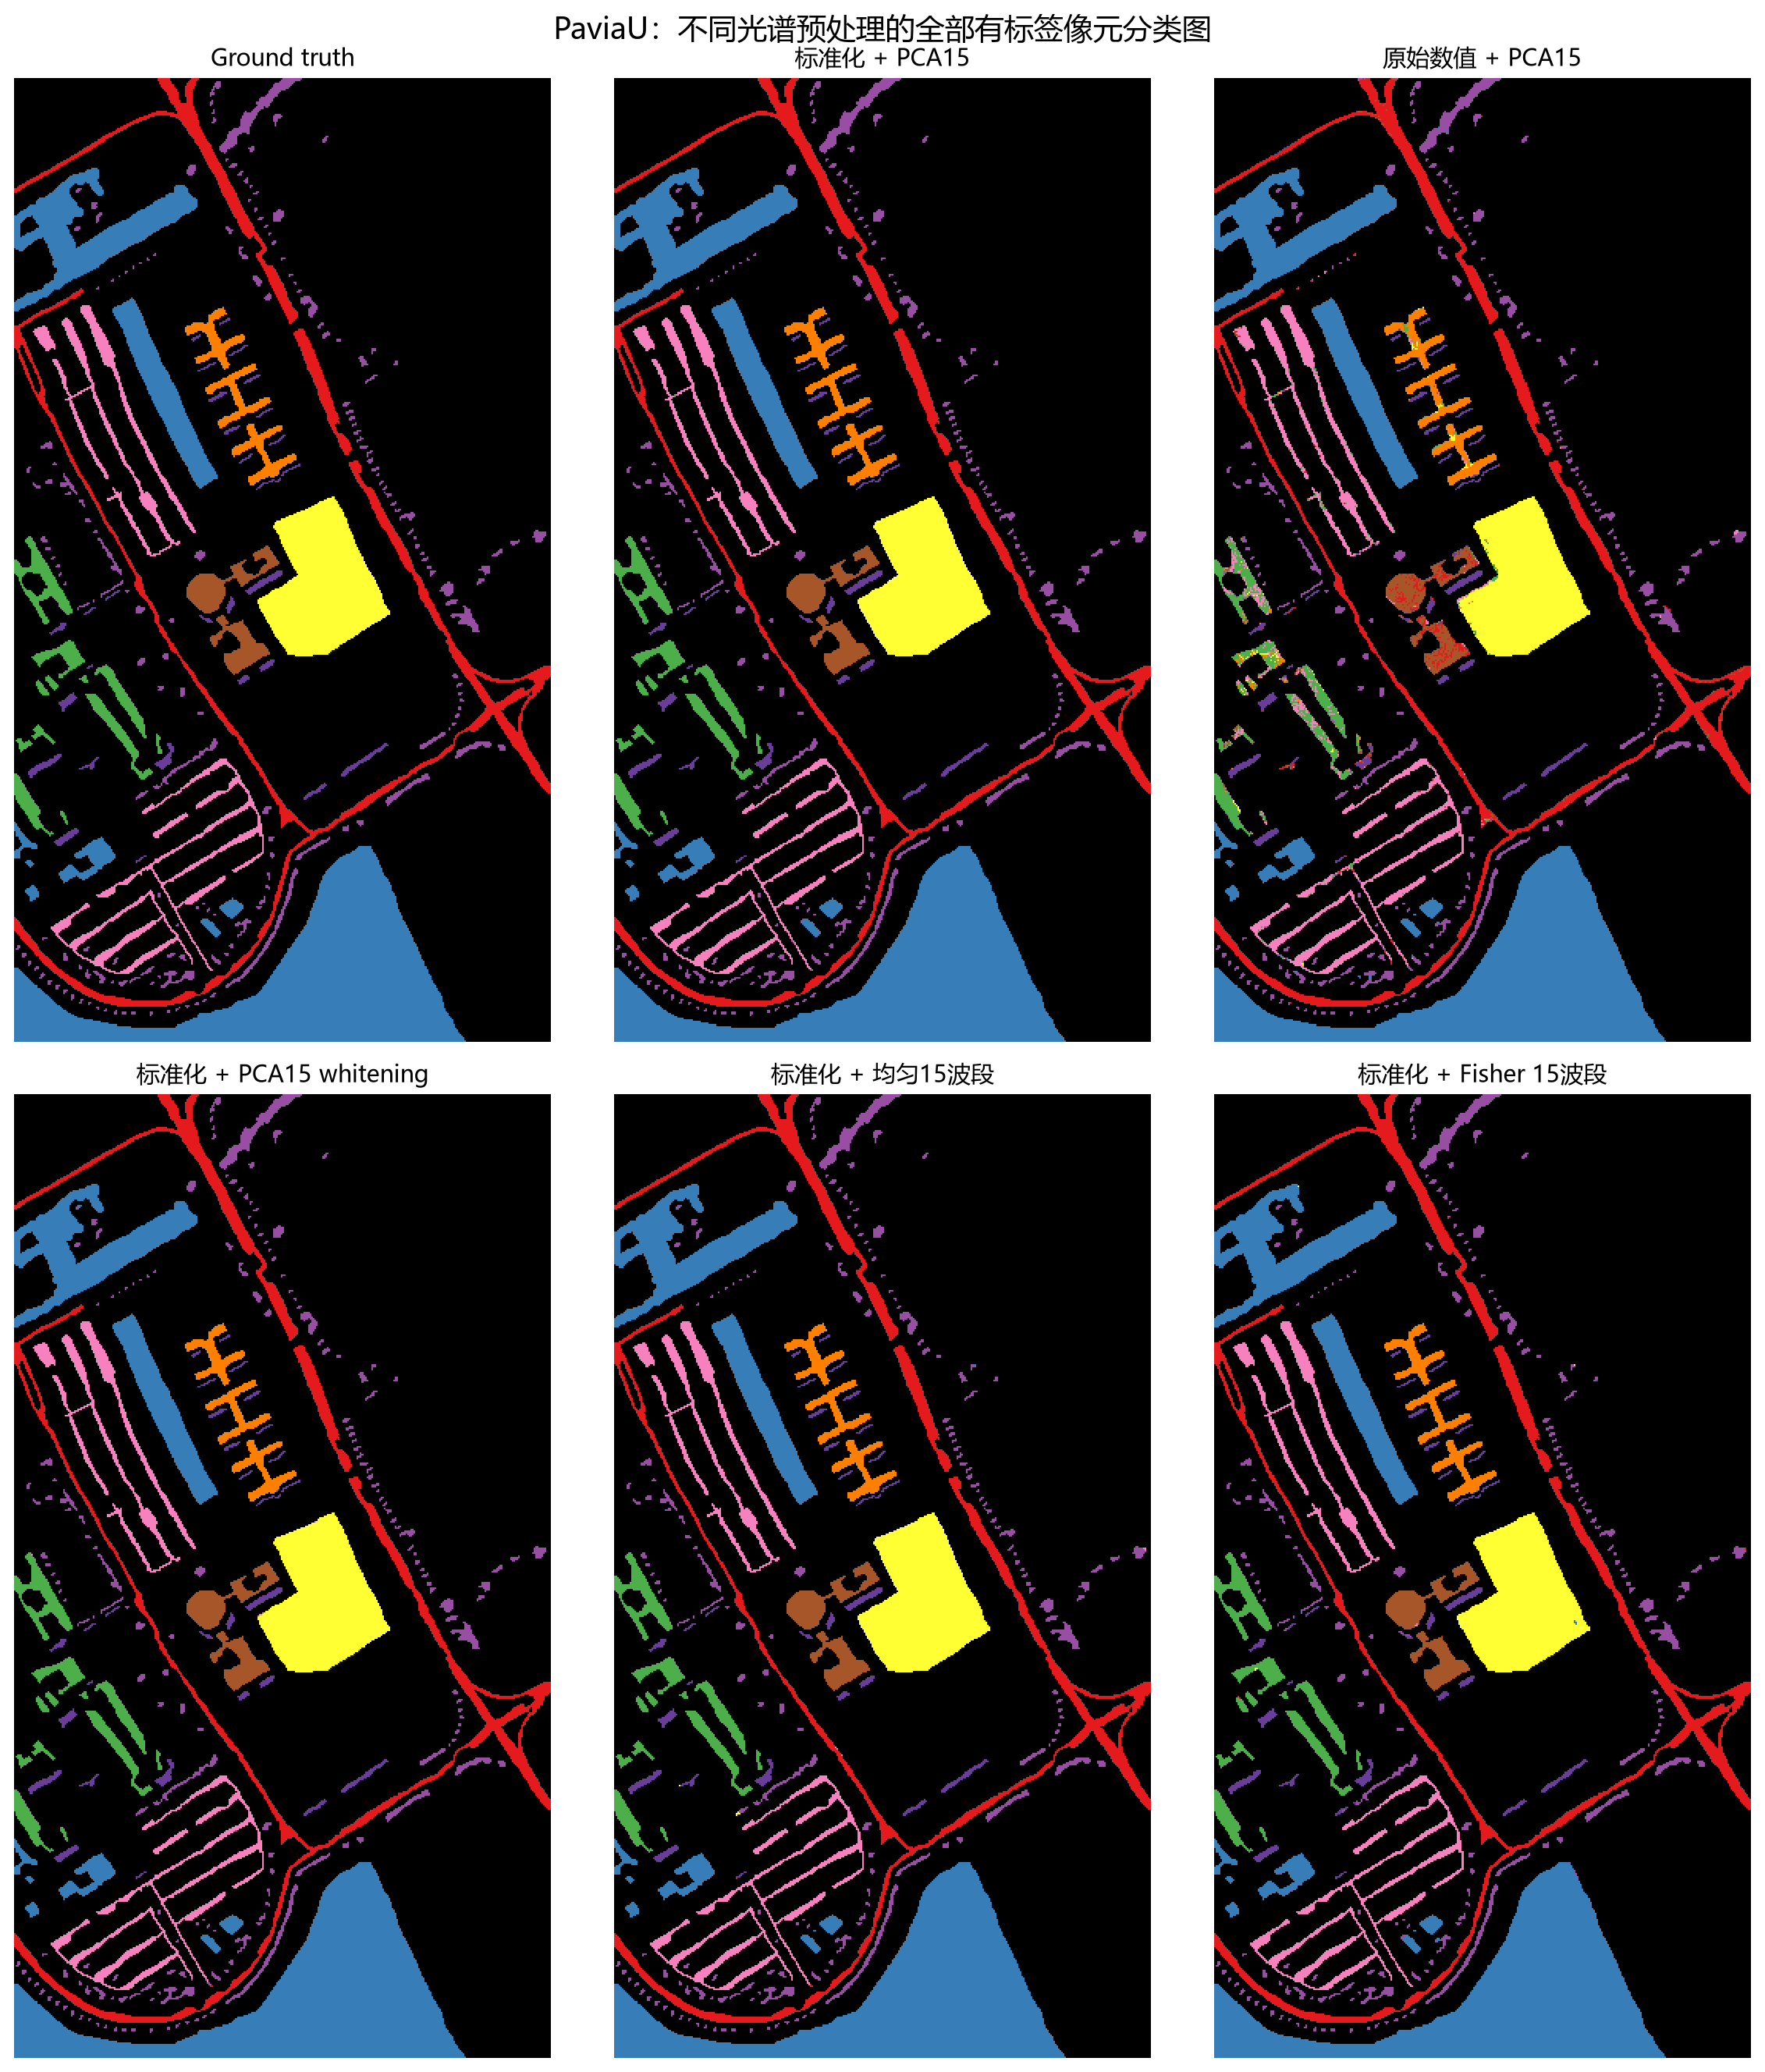

In [5]:
display(Image(filename=str(RUN_DIR / 'comparison_per_class_accuracy.png'), width=1200))
display(Image(filename=str(RUN_DIR / 'comparison_classification_maps.png'), width=1200))


### 如何阅读分类图

图中黑色区域是 Ground Truth 中未标注、因而没有纳入本次评价的位置，不是模型预测
出的“背景类别”。六联图使用全部 42,776 个有标签像元的预测，便于观察空间分布；
正式 OA/AA/Kappa 只来自固定的 29,944 个测试像元。


## 5. 各方法训练曲线



标准化 + PCA15


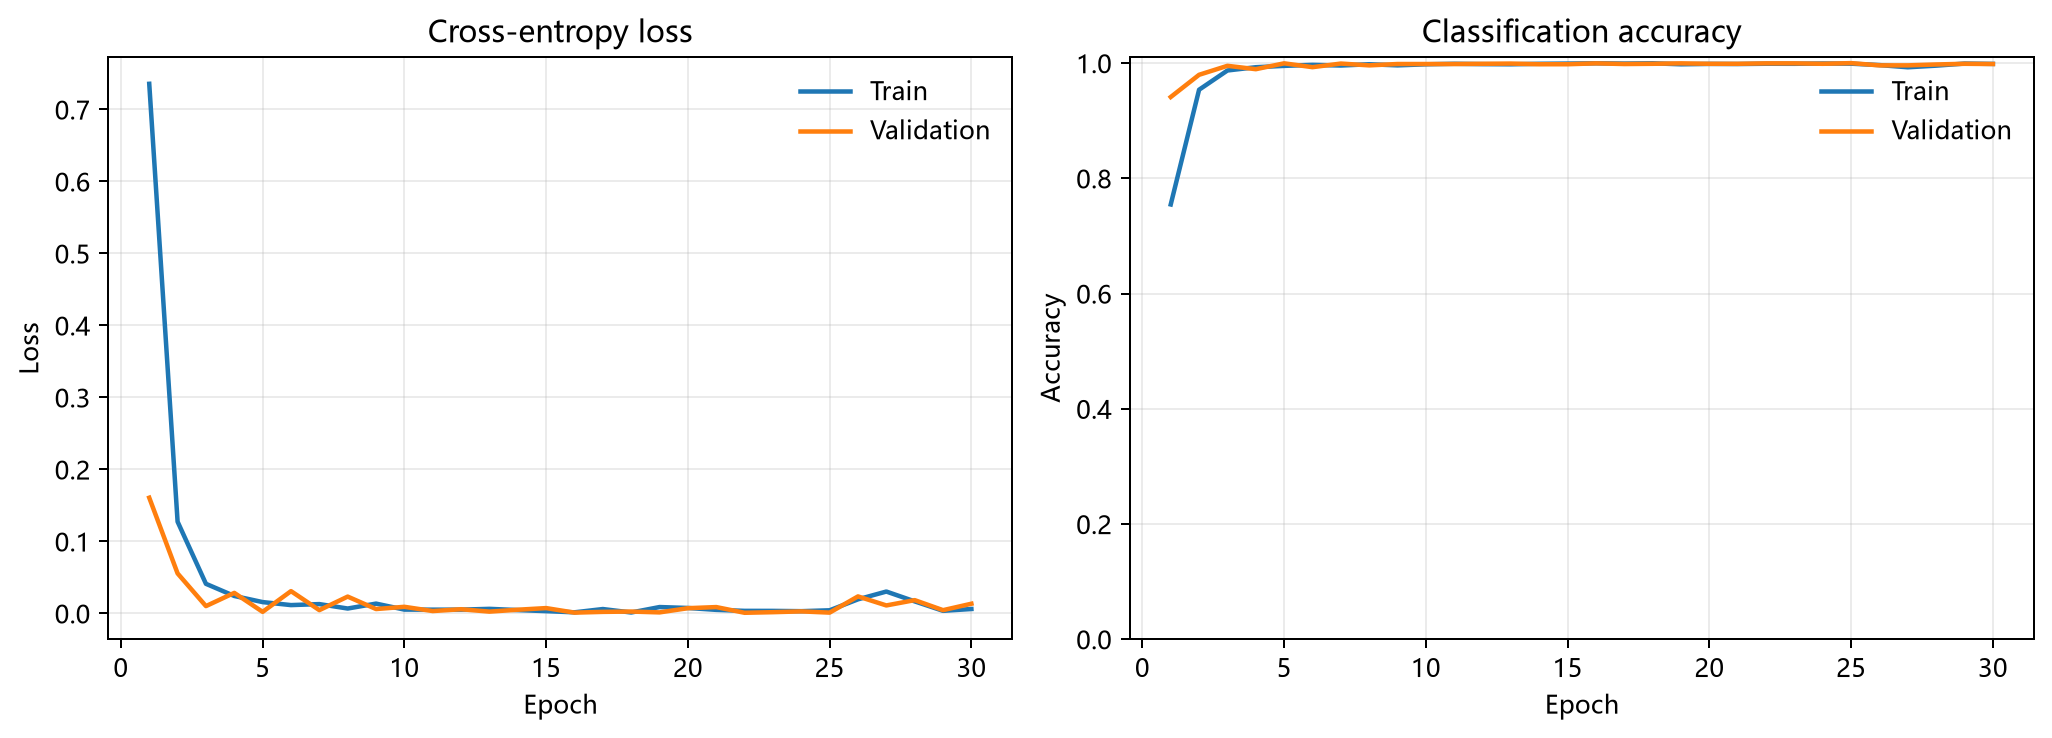


原始数值 + PCA15


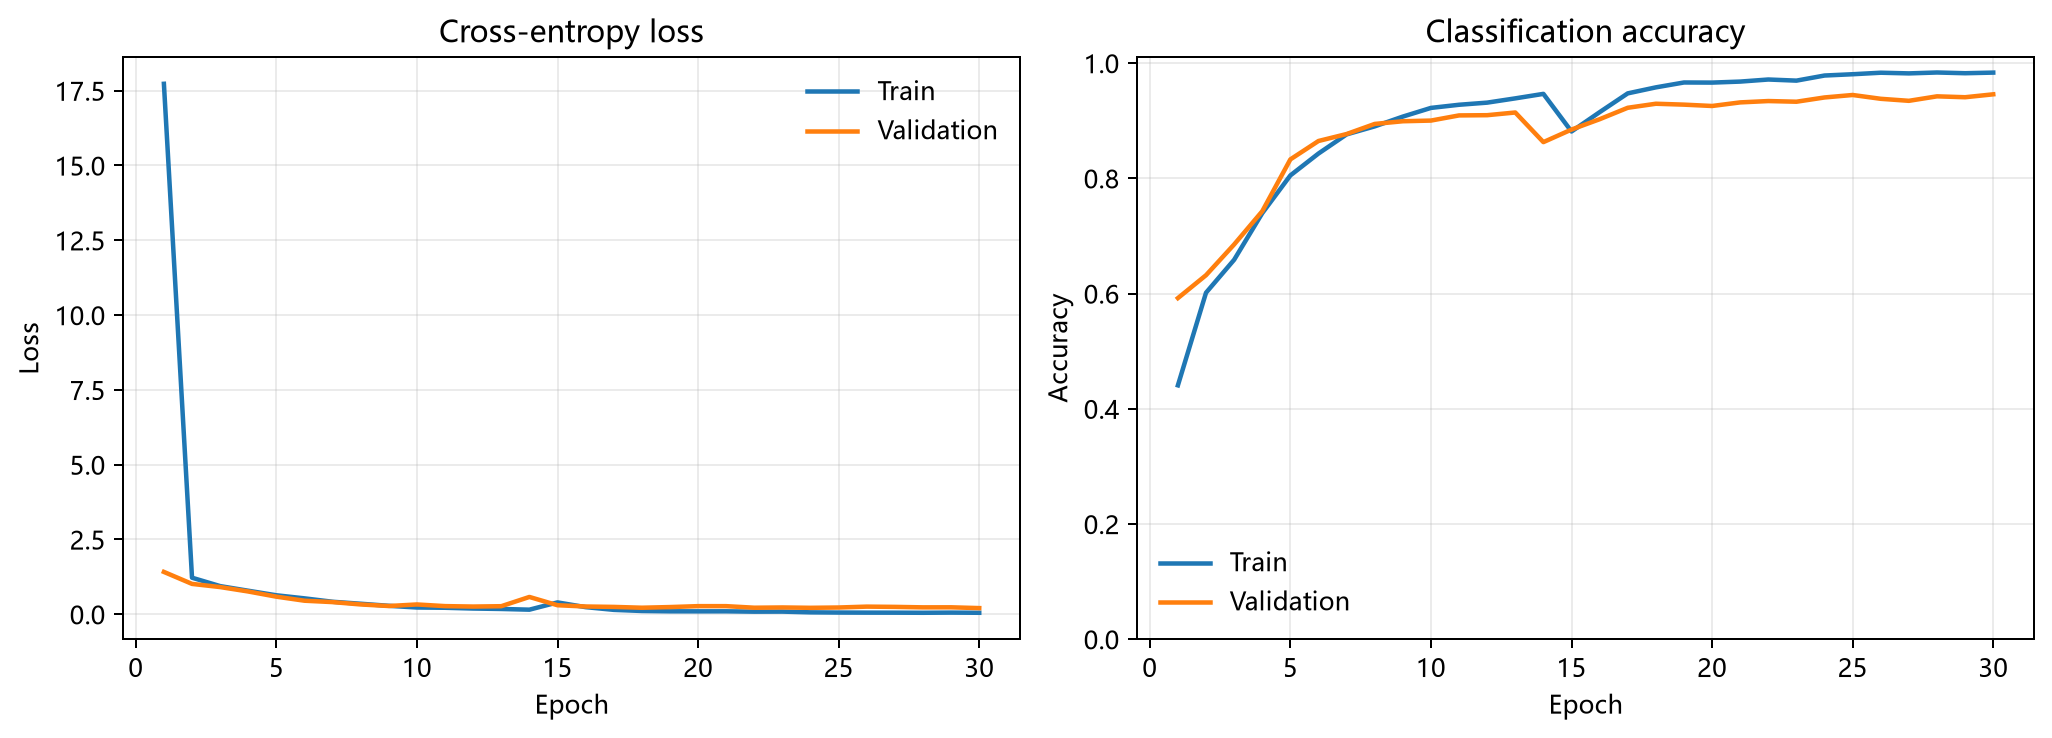


标准化 + PCA15 whitening


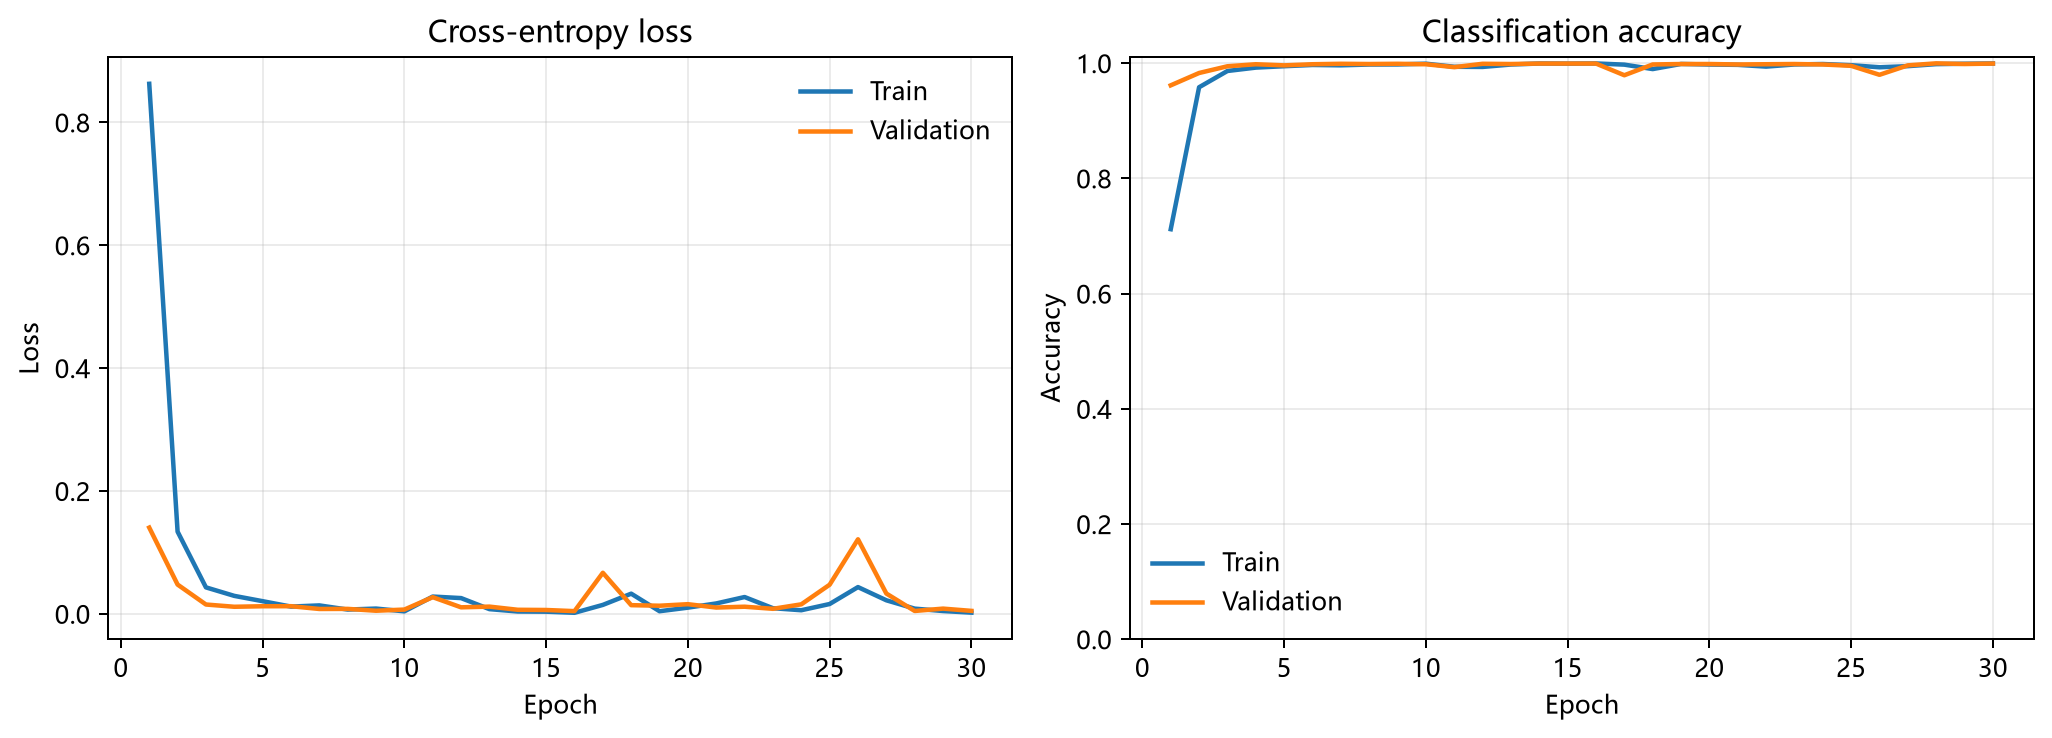


标准化 + 均匀15波段


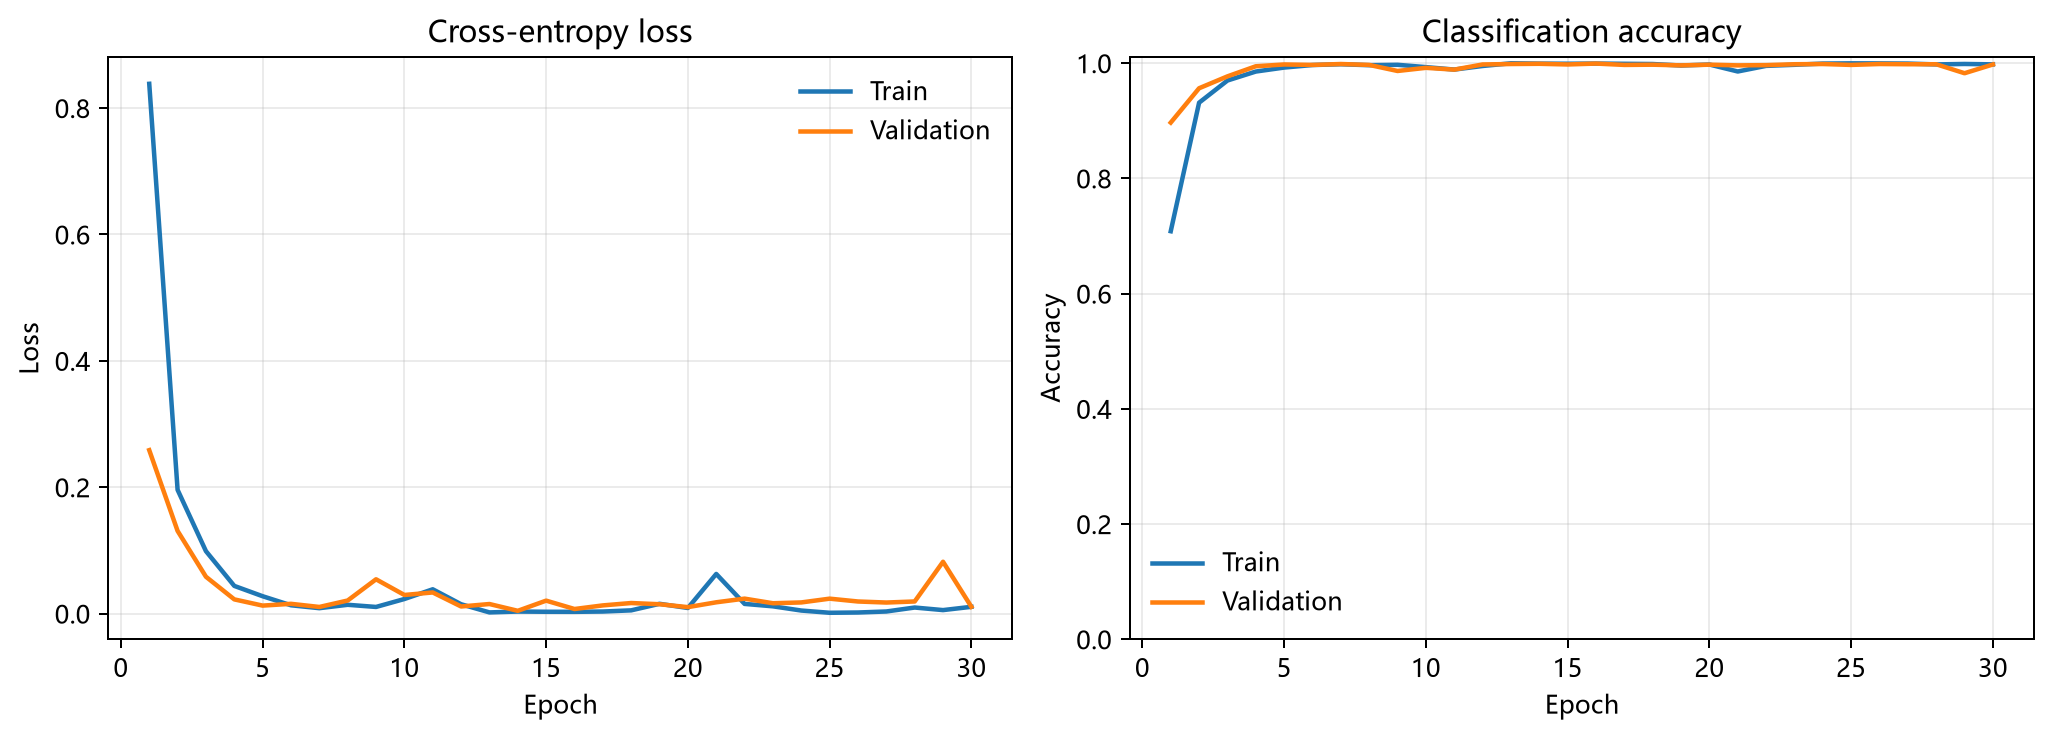


标准化 + Fisher 15波段


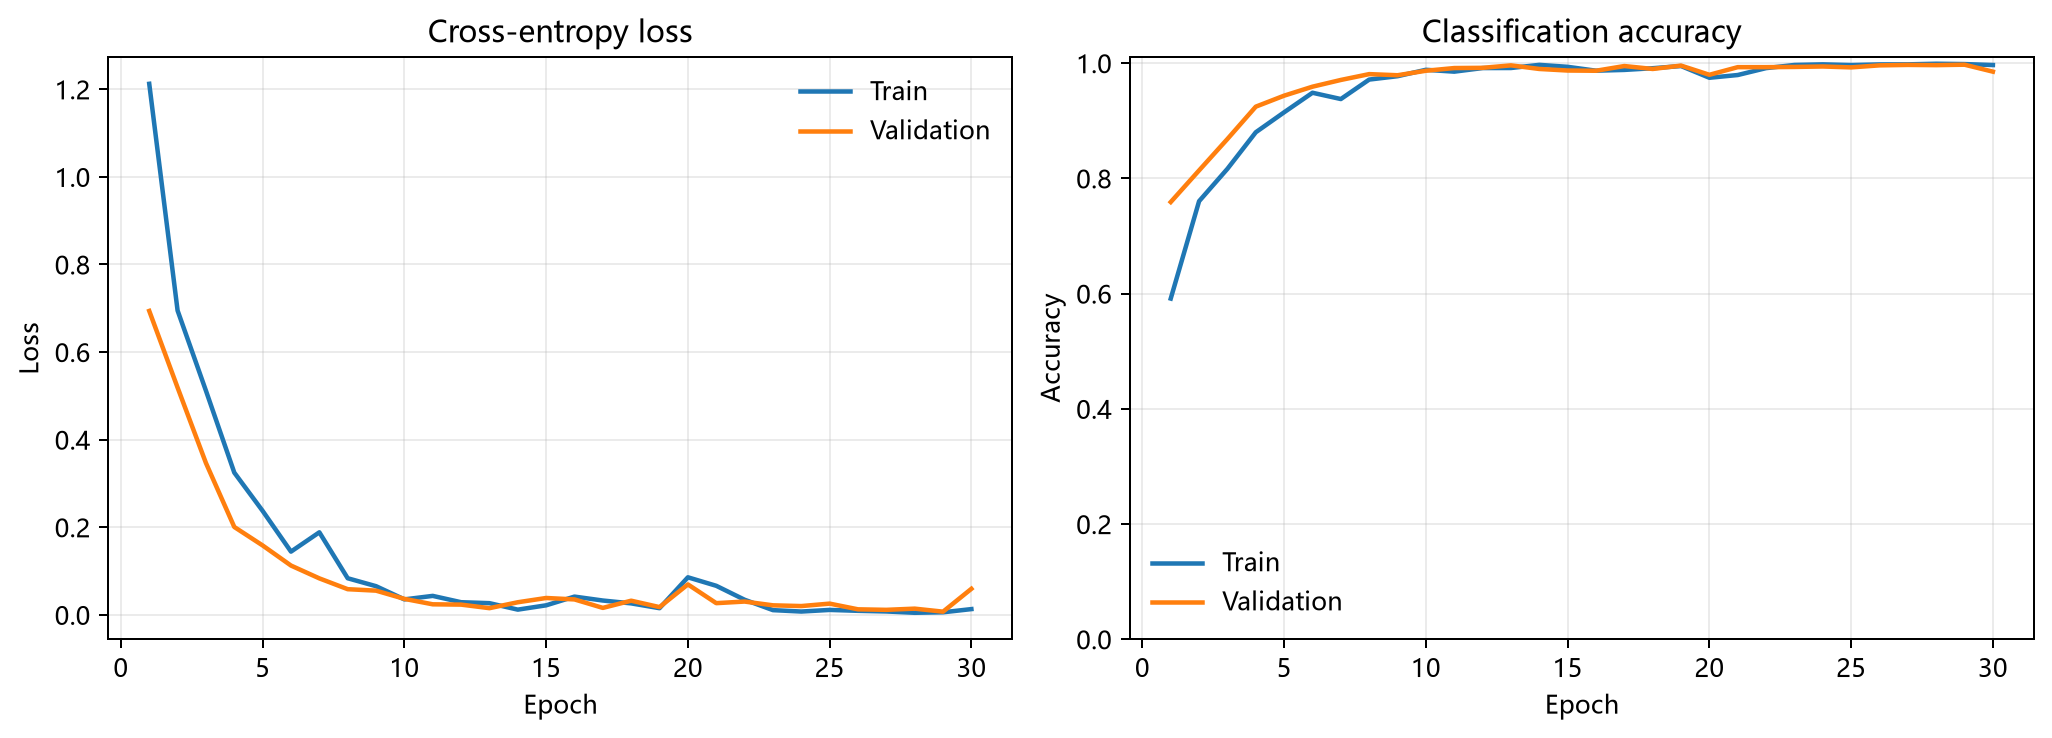

In [6]:
for row in summary.itertuples(index=False):
    print(f'\n{row.display_name}')
    display(Image(filename=str(RUN_DIR / row.variant_key / 'learning_curves.png'), width=900))


## 6. 空间重叠审计与解释边界


In [7]:
validation_overlap = json.loads(
    (RUN_DIR / 'validation_spatial_overlap_audit.json').read_text(encoding='utf-8')
)
test_overlap = json.loads(
    (RUN_DIR / 'test_spatial_overlap_audit.json').read_text(encoding='utf-8')
)
overlap_table = pd.DataFrame([
    {
        '查询集合': 'Validation',
        'patch内至少1个训练中心': validation_overlap['any_training_center_in_query_patch']['fraction_with_at_least_one'],
        'patch内至少1个同类训练中心': validation_overlap['same_class_training_center_in_query_patch']['fraction_with_at_least_one'],
        '训练中心中位数/patch': validation_overlap['any_training_center_in_query_patch']['median'],
    },
    {
        '查询集合': 'Test',
        'patch内至少1个训练中心': test_overlap['any_training_center_in_query_patch']['fraction_with_at_least_one'],
        'patch内至少1个同类训练中心': test_overlap['same_class_training_center_in_query_patch']['fraction_with_at_least_one'],
        '训练中心中位数/patch': test_overlap['any_training_center_in_query_patch']['median'],
    },
])
display(overlap_table.style.format({
    'patch内至少1个训练中心': '{:.4%}',
    'patch内至少1个同类训练中心': '{:.4%}',
    '训练中心中位数/patch': '{:.1f}',
}))


,查询集合,patch内至少1个训练中心,patch内至少1个同类训练中心,训练中心中位数/patch
0,Validation,99.9610%,99.9610%,72.0
1,Test,99.9833%,99.9666%,73.0


> 随机像元划分下，相邻像元可能分别进入训练、验证和测试，且 `25×25` patch
> 会高度重叠。因此这些 99% 以上结果适合课程协议内的预处理比较，不等价于跨区域、
> 跨城市或真正未知场景的泛化性能。


## 7. 这个任务到底是不是语义分割？

最准确的说法是：**基于光谱—空间邻域的逐像元高光谱图像分类**。

- 数据是 `610×340×103` 影像立方体，不是点云；每个二维像元拥有一条 103 波段光谱。
- 一个训练样本由“中心像元坐标 + 它周围的 `25×25` 邻域”构成。
- HybridSN 一次输出中心像元的一个九分类结果，不会一次输出整张二维 mask。
- 对许多中心坐标重复推理并回填后，结果外观与语义分割图相似。
- 因而它在**输出目标**上属于逐像元 dense labeling，在**网络计算形式**上是 patch
  classification，而不是 FCN/U-Net 式端到端 semantic segmentation。

```text
高光谱立方体 → 选中心坐标 → 光谱预处理 → 25×25 patch
              → HybridSN → 中心像元类别 → 多坐标回填成分类图
```

九个预测类别为 Asphalt、Meadows、Gravel、Trees、Painted metal sheets、Bare Soil、
Bitumen、Self-Blocking Bricks 和 Shadows。标签 0 只是未标注/背景掩膜，不参与九分类。


## 8. 导出 Word 报告素材


In [8]:
REPORT_DIR = PROJECT_ROOT / 'results/notebook_outputs/reference_aligned/preprocessing_comparison'
REPORT_DIR.mkdir(parents=True, exist_ok=True)
for filename in (
    'comparison_summary.csv', 'comparison_summary.json', 'comparison_metrics.png',
    'comparison_per_class_accuracy.png', 'comparison_classification_maps.png', '实验记录.md',
):
    shutil.copy2(RUN_DIR / filename, REPORT_DIR / filename)
for row in summary.itertuples(index=False):
    for filename in ('learning_curves.png', 'confusion_matrix.png', 'classification_map.png'):
        shutil.copy2(
            RUN_DIR / row.variant_key / filename,
            REPORT_DIR / f'{row.variant_key}__{filename}',
        )
result_table.to_csv(REPORT_DIR / 'Word结果主表.csv', index=False, encoding='utf-8-sig')
variant_detail_table.to_csv(REPORT_DIR / '预处理方法明细.csv', index=False, encoding='utf-8-sig')
overlap_table.to_csv(REPORT_DIR / '空间重叠审计摘要.csv', index=False, encoding='utf-8-sig')
print(f'已导出 {len(list(REPORT_DIR.iterdir()))} 个文件到：')
print(REPORT_DIR)


已导出 24 个文件到：
G:\高光谱智能图像解译\hsi_project\results\notebook_outputs\reference_aligned\preprocessing_comparison


## 9. 本次结论

本页结论必须以第 2 节 seed1442 的真实结果表为准。重点比较标准化、PCA whitening、
均匀原始波段与 Fisher 选波段；只按 validation OA 选择方案，测试集最高值仅作描述。
下一步可增加多 seed 均值±标准差和空间块划分，检验结论稳定性。
